# 04 — Model Training

Train LightGBM on all three horizons.  
Models are saved to `models/` for evaluation and live inference.

| Model | Input | Notes |
|---|---|---|
| LightGBM | flat (n, features) | early stopping on val set |


In [1]:
import sys
from pathlib import Path

# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import build_features, get_feature_cols
from src.models import LightGBMModel
from src.evaluate import chronological_split

PROCESSED = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

HORIZONS = ['5m', '30m', '1h']


## 1. Load & Feature-Engineer Data for All Horizons

In [2]:
feat_frames = {}
for label in HORIZONS:
    raw = pd.read_csv(PROCESSED / f'btc_{label}.csv',
                      index_col='timestamp', parse_dates=True)
    print(f"\n=== {label} ===")
    feat_frames[label] = build_features(raw)


=== 5m ===
[features] Building features  (rows before: 758,593) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 758,559,  features: 15)

=== 30m ===
[features] Building features  (rows before: 126,433) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 126,399,  features: 15)

=== 1h ===
[features] Building features  (rows before: 63,217) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 63,183,  features: 15)


## 2. Prepare Splits

In [3]:
splits = {}  # splits[horizon] = (train_df, val_df, test_df)

for label, df in feat_frames.items():
    print(f"\n--- {label} ---")
    train, val, test = chronological_split(df)
    splits[label] = (train, val, test)


--- 5m ---
[eval] Split → train 530,991  val 113,784  test 113,784  (2019-01-01 / 2024-01-18 / 2025-02-16)

--- 30m ---
[eval] Split → train 88,479  val 18,960  test 18,960  (2019-01-01 / 2024-01-19 / 2025-02-17)

--- 1h ---
[eval] Split → train 44,228  val 9,477  test 9,478  (2019-01-02 / 2024-01-19 / 2025-02-17)


In [4]:
# Prepare flat arrays for LightGBM
flat_splits = {}  # flat_splits[horizon] = ((Xtr,ytr), (Xvl,yvl), (Xte,yte))

for label, df in feat_frames.items():
    feat_cols = get_feature_cols(df)
    X_flat = df[feat_cols].values.astype(np.float32)
    y_flat = df['target'].values.astype(np.float32)

    n = len(y_flat)
    tr = int(n * 0.70)
    vl = int(n * 0.85)
    flat_splits[label] = (
        (X_flat[:tr],    y_flat[:tr]),
        (X_flat[tr:vl],  y_flat[tr:vl]),
        (X_flat[vl:],    y_flat[vl:]),
    )
    print(f"{label}: train={tr:,}  val={vl-tr:,}  test={n-vl:,}")


5m: train=530,991  val=113,784  test=113,784
30m: train=88,479  val=18,960  test=18,960
1h: train=44,228  val=9,477  test=9,478


## 3. LightGBM

In [5]:
lgbm_models = {}

for label in HORIZONS:
    print(f"\n=== LGBM — {label} ===")
    (Xtr, ytr), (Xvl, yvl), _ = flat_splits[label]

    model = LightGBMModel()
    model.train(Xtr, ytr, Xvl, yvl)
    model.save(MODEL_DIR / f'lgbm_{label}.pkl')
    lgbm_models[label] = model


=== LGBM — 5m ===
[LGBM] Training …
[LightGBM] [Info] Number of positive: 265348, number of negative: 265643
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3346
[LightGBM] [Info] Number of data points in the train set: 530991, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499722 -> initscore=-0.001111
[LightGBM] [Info] Start training from score -0.001111
Training until validation scores don't improve for 30 rounds
[50]	valid_0's binary_logloss: 0.692329
Early stopping, best iteration is:
[22]	valid_0's binary_logloss: 0.692157
[LGBM] Best iteration: 22
[LGBM] Saved → /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_5m.pkl

=== LGBM — 30m ===
[LGBM] Training …
[LightGBM] [Info] Number of positive: 44792, number of neg

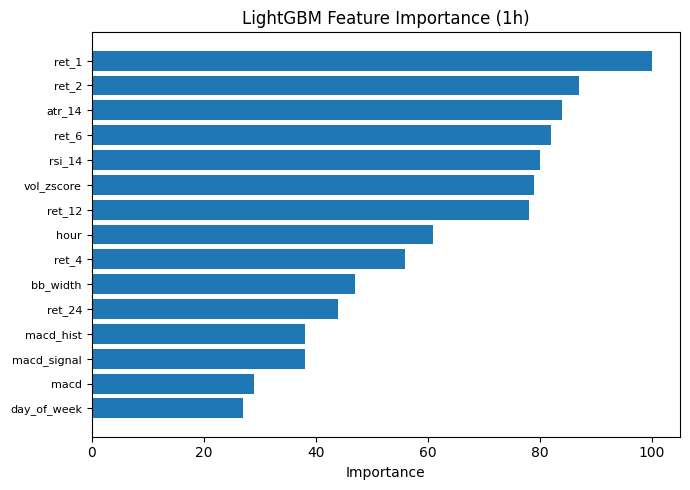

In [6]:
# Feature importance for LightGBM (1h as example)
from src.evaluate import plot_feature_importance

feat_cols_1h = get_feature_cols(feat_frames['1h'])
fig, ax = plt.subplots(figsize=(7, 5))
plot_feature_importance(
    lgbm_models['1h'].feature_importances_,
    feat_cols_1h,
    top_n=len(feat_cols_1h),
    title='LightGBM Feature Importance (1h)',
    ax=ax,
)
plt.tight_layout()
plt.show()

## Summary

LightGBM models trained and saved to `models/`:
```
models/
  lgbm_5m.pkl    lgbm_30m.pkl    lgbm_1h.pkl
```

Proceed to `05_evaluation.ipynb` for test-set metrics.
